# 第 9 课：前沿 ASR 语言模型系统设计实验室

更新范围：截至 **2026-08-18**。这一课不追逐一个“万能大模型”，而是把前沿论文还原成可验证的系统选择。

完成后你应该能够：

1. 解释为什么现代系统仍保留低延迟 CTC/RNN-T + N-gram/WFST 基线；
2. 区分检索式 contextual ASR、N-best 重打分、生成式纠错和 SpeechLLM；
3. 设计音频证据门控与不可信时回退；
4. 同时评测 WER、实体错误、幻觉、延迟和资源；
5. 产出一份可复现的前沿实验计划。

完整论文清单见 [ASR 语言模型前沿论文与系统路线](../FRONTIER_ASR_LM_READING.md)。


## 0. 推荐的现代混合系统

```mermaid
flowchart LR
    A[音频] --> B[流式 CTC/RNN-T 一遍解码]
    C[N-gram / WFST / 热词图] --> B
    B --> D[lattice / N-best / posterior / timestamp]
    D --> E[上下文检索]
    F[实体库 / 文档 / 会话状态] --> E
    D --> G[音频条件二遍模型]
    E --> G
    G --> H[声学一致性与幻觉门控]
    H --> I[最终文本]
    H -->|拒绝时回退| D
```

这是对多篇论文的工程综合推断，不是某篇论文声称的唯一架构。第一遍负责低延迟、硬约束和稳定回退；后续模块利用长上下文与外部知识，但必须保留音频证据。


## 1. 论文地图：每篇只回答一个关键问题

| 问题 | 代表工作 | 阅读时追问 |
|---|---|---|
| 中文文本纠错是否可靠 | [ASR-EC Benchmark](https://aclanthology.org/2025.emnlp-industry.110/) | text-only、微调、音频增强差在哪里 |
| 怎样从大实体库取少量上下文 | [RECAST](https://aclanthology.org/2025.findings-emnlp.203/) | decoder state 怎样检索 keyword |
| 怎样把 CTC 不确定性送给 LLM | [LegoSLM](https://arxiv.org/abs/2505.11352) | posterior 为什么优于硬 1-best |
| 怎样解决语音帧与文本 token 粒度差 | [SEAM](https://aclanthology.org/2026.findings-eacl.112/) | variable-rate adapter 在对齐什么 |
| 怎样让文本预训练真正进入 SpeechLLM | [JSTIP](https://arxiv.org/abs/2607.01733) | speech-text interleaving 的消融是什么 |
| 怎样使用宽泛上下文推理 | [Metadata-Driven Reasoning](https://arxiv.org/abs/2606.10838) | 相关但未说出的内容会不会被插入 |
| 怎样在线发现 SpeechLLM 幻觉 | [Attention-map Detection](https://aclanthology.org/2026.findings-acl.2147/) | detector 跨模型/跨任务是否泛化 |

不要只抄论文总 WER。至少记录：输入证据、是否允许生成新文本、训练数据、对照基线、实体指标、幻觉定义、延迟和限制。


In [1]:
from pathlib import Path
import json
import re
import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import display

def find_project_root():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('请从 learn_asr 项目或 notebooks 目录启动 Jupyter')

ROOT = find_project_root()
LAB = ROOT / 'openfst_lab' / 'lesson09'
LAB.mkdir(parents=True, exist_ok=True)
print('实验目录：', LAB)


实验目录： <REPO_ROOT>\openfst_lab\lesson09


## 2. 检索式 contextual ASR：先缩小上下文，再偏置

把数万实体全部塞进 prompt 会增加长度、延迟和误触发。RECAST 的核心启发是从 ASR decoder state 检索少量相关 keyword。下面使用字符 bigram 相似度做可见的教学替代；它不是 RECAST 模型复现。


In [2]:
ENTITY_DB = ['zyrtec', 'zyrtek', 'zyritec', 'sirtec', 'circuit', 'openfst', 'kenlm', 'kaldi']

def normalize_text(text):
    return re.sub(r'[^a-z0-9]+', '', text.lower())

def char_ngrams(text, n=2):
    normalized = normalize_text(text)
    return {normalized[i:i+n] for i in range(max(0, len(normalized) - n + 1))}

def jaccard(left, right):
    union = left | right
    return len(left & right) / len(union) if union else 0.0

def retrieve_entities(decoder_hint, top_k=3):
    query = char_ngrams(decoder_hint)
    ranked = sorted(
        ((entity, jaccard(query, char_ngrams(entity))) for entity in ENTITY_DB),
        key=lambda item: (-item[1], item[0]),
    )
    return ranked[:top_k]

retrieved = retrieve_entities('zyr tec', top_k=4)
print('检索结果：')
for entity, similarity in retrieved:
    print(f'{entity:10s} similarity={similarity:.3f}')
assert retrieved[0][0] == 'zyrtec'


检索结果：
zyrtec     similarity=1.000
zyrtek     similarity=0.667
zyritec    similarity=0.571
sirtec     similarity=0.429


## 3. 把检索分数作为路径代价，而不是字符串替换

候选同时保留声学代价和 N-gram 代价。检索命中的实体获得与相似度成比例的 context bonus：

$$C = C_{acoustic} + \alpha C_{ngram} - \gamma S_{retrieval}$$

以下数字全部是教学模拟，不是论文报告结果。


In [3]:
CANDIDATES = [
    {'text': 'call zyrtec support',   'entity': 'zyrtec',  'acoustic': 1.10, 'ngram': 3.00},
    {'text': 'call sir tech support', 'entity': '',        'acoustic': 1.30, 'ngram': 1.50},
    {'text': 'call zyrtek support',   'entity': 'zyrtek',  'acoustic': 1.15, 'ngram': 2.70},
    {'text': 'call circuit support',  'entity': 'circuit', 'acoustic': 1.80, 'ngram': 1.30},
]
retrieval_scores = dict(retrieved)

def contextual_rank(lm_scale=0.5, context_scale=0.0):
    ranked = []
    for candidate in CANDIDATES:
        retrieval = retrieval_scores.get(candidate['entity'], 0.0)
        total = candidate['acoustic'] + lm_scale * candidate['ngram'] - context_scale * retrieval
        ranked.append({**candidate, 'retrieval': retrieval, 'total': total})
    return sorted(ranked, key=lambda item: item['total'])

for context_scale in [0.0, 0.5, 1.0, 1.5]:
    best = contextual_rank(context_scale=context_scale)[0]
    print(f'context scale={context_scale:.1f} → {best["text"]:24s} cost={best["total"]:.3f}')
assert contextual_rank(context_scale=0.0)[0]['text'] == 'call sir tech support'
assert contextual_rank(context_scale=1.0)[0]['text'] == 'call zyrtec support'


context scale=0.0 → call sir tech support    cost=2.050
context scale=0.5 → call sir tech support    cost=2.050
context scale=1.0 → call zyrtec support      cost=1.600
context scale=1.5 → call zyrtec support      cost=1.100


## 4. 音频条件纠错：流畅不等于忠实

text-only LLM 容易把候选改得更通顺，却可能加入音频中不存在的词。音频条件模型或 CTC posterior adapter 的价值，是让二遍模型仍能访问声学不确定性。

下面模拟三个纠错提案。`audio_support`、`confidence` 是教学特征；真实系统应由音频编码器、CTC posterior、交叉注意力或校准模型产生。


In [4]:
FIRST_PASS = 'call sir tech support'
PROPOSALS = [
    {'name': 'text-only GER', 'text': 'call zyrtec customer support',
     'audio_support': 0.62, 'confidence': 0.91, 'unsupported_insertions': 1},
    {'name': 'audio-conditioned GER', 'text': 'call zyrtec support',
     'audio_support': 0.94, 'confidence': 0.87, 'unsupported_insertions': 0},
    {'name': 'hallucinated long output', 'text': 'call zyrtec support tomorrow morning',
     'audio_support': 0.45, 'confidence': 0.83, 'unsupported_insertions': 2},
]

def word_edit_distance(reference, hypothesis):
    reference, hypothesis = reference.split(), hypothesis.split()
    table = [[0] * (len(hypothesis) + 1) for _ in range(len(reference) + 1)]
    for i in range(len(reference) + 1): table[i][0] = i
    for j in range(len(hypothesis) + 1): table[0][j] = j
    for i in range(1, len(reference) + 1):
        for j in range(1, len(hypothesis) + 1):
            table[i][j] = min(
                table[i-1][j] + 1, table[i][j-1] + 1,
                table[i-1][j-1] + (reference[i-1] != hypothesis[j-1]),
            )
    return table[-1][-1]

def gate_proposal(proposal, audio_threshold=0.8, confidence_threshold=0.7, max_edits=2):
    reasons = []
    if proposal['audio_support'] < audio_threshold: reasons.append('声学支持不足')
    if proposal['confidence'] < confidence_threshold: reasons.append('置信度不足')
    if proposal['unsupported_insertions'] > 0: reasons.append('存在无证据插入')
    if word_edit_distance(FIRST_PASS, proposal['text']) > max_edits: reasons.append('改动过大')
    return {'accepted': not reasons, 'reasons': reasons,
            'output': proposal['text'] if not reasons else FIRST_PASS}

for proposal in PROPOSALS:
    decision = gate_proposal(proposal)
    print(f'{proposal["name"]:24s} accepted={decision["accepted"]} '          f'output={decision["output"]} reasons={decision["reasons"]}')
assert gate_proposal(PROPOSALS[0])['accepted'] is False
assert gate_proposal(PROPOSALS[1])['accepted'] is True


text-only GER            accepted=False output=call sir tech support reasons=['声学支持不足', '存在无证据插入']
audio-conditioned GER    accepted=True output=call zyrtec support reasons=[]
hallucinated long output accepted=False output=call sir tech support reasons=['声学支持不足', '存在无证据插入', '改动过大']


## 5. Coverage–risk：门控不是只报一个阈值

阈值越严格，接受的纠错越少，通常错误风险也会下降。生产系统应画 coverage–risk 曲线：覆盖率表示多少样本接受二遍结果，risk 表示已接受样本中的错误率。


threshold=0.5 coverage=0.90 risk=0.33
threshold=0.7 coverage=0.70 risk=0.29
threshold=0.8 coverage=0.50 risk=0.20
threshold=0.9 coverage=0.30 risk=0.00


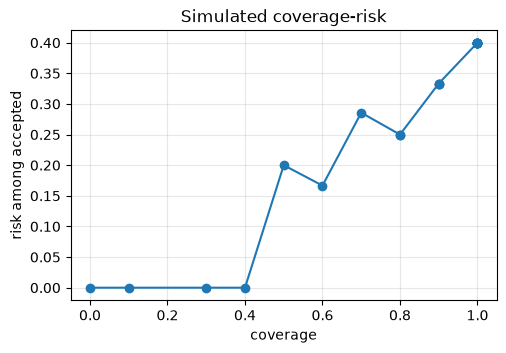

In [5]:
GATE_DATA = [
    {'score': 0.97, 'correct': True}, {'score': 0.93, 'correct': True},
    {'score': 0.90, 'correct': True}, {'score': 0.86, 'correct': True},
    {'score': 0.82, 'correct': False}, {'score': 0.77, 'correct': True},
    {'score': 0.71, 'correct': False}, {'score': 0.66, 'correct': True},
    {'score': 0.58, 'correct': False}, {'score': 0.42, 'correct': False},
]

def coverage_risk(threshold):
    accepted = [item for item in GATE_DATA if item['score'] >= threshold]
    coverage = len(accepted) / len(GATE_DATA)
    risk = sum(not item['correct'] for item in accepted) / len(accepted) if accepted else 0.0
    return coverage, risk

thresholds = [index / 20 for index in range(21)]
points = [coverage_risk(threshold) for threshold in thresholds]
for threshold in [0.5, 0.7, 0.8, 0.9]:
    coverage, risk = coverage_risk(threshold)
    print(f'threshold={threshold:.1f} coverage={coverage:.2f} risk={risk:.2f}')
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot([point[0] for point in points], [point[1] for point in points], marker='o')
ax.set_xlabel('coverage')
ax.set_ylabel('risk among accepted')
ax.set_title('Simulated coverage-risk')
ax.grid(alpha=0.3)
plt.show()


## 6. 不存在单一“最好系统”：看多目标 Pareto

下面的指标也是教学模拟，用于练习系统选择，**不能引用为论文结果**。所有列都是越低越好。低延迟基线、检索增强、音频条件纠错和 SpeechLLM 会处在不同折中点。


In [6]:
SYSTEMS = [
    {'name': 'CTC+WFST baseline',       'wer': 9.8, 'entity_wer': 28.0, 'hallucination': 0.0, 'latency': 55,  'memory': 1.0},
    {'name': '+ retrieval context',     'wer': 9.1, 'entity_wer': 18.0, 'hallucination': 0.2, 'latency': 70,  'memory': 1.2},
    {'name': 'text-only LLM GER',       'wer': 8.7, 'entity_wer': 19.0, 'hallucination': 2.8, 'latency': 240, 'memory': 8.0},
    {'name': 'audio-conditioned GER',   'wer': 7.9, 'entity_wer': 14.0, 'hallucination': 1.1, 'latency': 310, 'memory': 10.0},
    {'name': 'end-to-end SpeechLLM',    'wer': 7.6, 'entity_wer': 12.0, 'hallucination': 2.0, 'latency': 420, 'memory': 16.0},
    {'name': 'gated hybrid + fallback', 'wer': 8.0, 'entity_wer': 14.0, 'hallucination': 0.3, 'latency': 330, 'memory': 10.5},
]
METRICS = ['wer', 'entity_wer', 'hallucination', 'latency', 'memory']

def dominates(left, right):
    no_worse = all(left[metric] <= right[metric] for metric in METRICS)
    strictly_better = any(left[metric] < right[metric] for metric in METRICS)
    return no_worse and strictly_better

for system in SYSTEMS:
    pareto = not any(dominates(other, system) for other in SYSTEMS if other is not system)
    print(('★ Pareto' if pareto else '  dominated'), system['name'])


★ Pareto CTC+WFST baseline
★ Pareto + retrieval context
★ Pareto text-only LLM GER
★ Pareto audio-conditioned GER
★ Pareto end-to-end SpeechLLM
★ Pareto gated hybrid + fallback


## 7. 前沿实验最小消融矩阵

每次只新增一个能力，才能知道收益来自哪里：

| 系统 | 音频证据 | 外部上下文 | 可生成新文本 | 必须报告 |
|---|---|---|---:|---|
| CTC/RNN-T + WFST | 完整 | N-gram/热词图 | 否 | WER、实体 WER、RTF |
| N-best + neural LM | 间接 | 文本语料 | 否 | oracle WER、重排增益 |
| + retrieval context | 间接/decoder state | 实体库 | 否或受限 | recall、误触发、延迟 |
| text-only GER | 无直接音频 | prompt/检索 | 是 | 误改、无证据插入 |
| audio-conditioned GER | 有 | N-best/检索 | 是 | 声学一致性、门控曲线 |
| speech encoder + adapter + LLM | 有 | prompt/检索 | 是 | 跨域、实体、幻觉、显存 |

不能把 text-only LLM 与弱基线比较后就声称 SpeechLLM 有效；至少加入相同 N-best、相同上下文、相同参数预算的对照。


## 8. 为你的第一项前沿复现实验选路线

对刚完成 OpenFst/N-gram 基础的学习者，推荐顺序是：检索式 contextual ASR → N-best neural LM → 音频条件纠错 → SpeechLLM adapter。第一项路线成本最低，因果对照也最清楚。


In [7]:
TRACKS = {
    '检索式 contextual ASR（推荐起点）': {
        'build': 'decoder/text query → top-k entity retrieval → lattice/context score',
        'baseline': 'CTC/RNN-T + N-gram/WFST + 固定热词表',
        'metrics': 'WER、entity WER、retrieval recall@k、误触发率、延迟',
        'risk': '检索错误把无关实体注入解码',
    },
    'N-best neural/LLM 重打分': {
        'build': '保留 acoustic/ngram score，对 N-best 计算 neural LM cost',
        'baseline': '第 8 课冻结的 N-gram 融合系统',
        'metrics': 'WER、oracle WER@k、rescoring gain、延迟',
        'risk': '候选已被剪掉时无法恢复',
    },
    '音频条件生成式纠错': {
        'build': 'N-best + CTC posterior/audio embedding → minimal-edit GER → gate',
        'baseline': '相同 N-best 的 text-only GER 与只重排系统',
        'metrics': 'WER、无证据插入、coverage–risk、回退率、延迟',
        'risk': '语言上流畅但声音上错误',
    },
    'SpeechLLM adapter / interleaving': {
        'build': 'speech encoder + CTC/variable-rate adapter + LLM',
        'baseline': '同数据预算的 ASR-only 与普通 joint training',
        'metrics': 'WER、entity WER、跨域、幻觉、显存、吞吐',
        'risk': '训练成本高，LLM 文本先验可能压过音频',
    },
}
track_widget = widgets.Dropdown(options=list(TRACKS), description='路线：', layout=widgets.Layout(width='620px'))
track_output = widgets.Output()

def show_track(change=None):
    with track_output:
        track_output.clear_output(wait=True)
        info = TRACKS[track_widget.value]
        for key, value in info.items():
            print(f'{key:9s}: {value}')

track_widget.observe(show_track, names='value')
display(track_widget, track_output)
show_track()


Dropdown(description='路线：', layout=Layout(width='620px'), options=('检索式 contextual ASR（推荐起点）', 'N-best neural/…

Output()

## 9. 生成一份可复现实验计划

把 `PROJECT_CHOICE` 改成你选择的路线键。生成的 JSON 是起点，不是实验结论；只有真实训练、冻结测试集并运行后才能填写结果。


In [8]:
PROJECT_CHOICE = '检索式 contextual ASR（推荐起点）'
assert PROJECT_CHOICE in TRACKS
choice = TRACKS[PROJECT_CHOICE]
experiment_plan = {
    'title': PROJECT_CHOICE,
    'research_question': '新增模块是否在相同候选、数据和延迟预算下带来可归因改善？',
    'system_to_build': choice['build'],
    'frozen_baseline': choice['baseline'],
    'data_split': {'train': '用于训练', 'dev': '选择超参数与阈值', 'test': '冻结后只评一次'},
    'required_metrics': choice['metrics'],
    'known_risk': choice['risk'],
    'ablations': ['去掉外部上下文', '去掉音频证据', '去掉门控/回退', '匹配参数与延迟预算'],
    'status': 'planned-not-run',
}
plan_path = LAB / 'frontier_experiment_plan.json'
plan_path.write_text(json.dumps(experiment_plan, ensure_ascii=False, indent=2), encoding='utf-8')
print(json.dumps(experiment_plan, ensure_ascii=False, indent=2))
print('已保存：', plan_path)


{
  "title": "检索式 contextual ASR（推荐起点）",
  "research_question": "新增模块是否在相同候选、数据和延迟预算下带来可归因改善？",
  "system_to_build": "decoder/text query → top-k entity retrieval → lattice/context score",
  "frozen_baseline": "CTC/RNN-T + N-gram/WFST + 固定热词表",
  "data_split": {
    "train": "用于训练",
    "dev": "选择超参数与阈值",
    "test": "冻结后只评一次"
  },
  "required_metrics": "WER、entity WER、retrieval recall@k、误触发率、延迟",
  "known_risk": "检索错误把无关实体注入解码",
  "ablations": [
    "去掉外部上下文",
    "去掉音频证据",
    "去掉门控/回退",
    "匹配参数与延迟预算"
  ],
  "status": "planned-not-run"
}
已保存： <REPO_ROOT>\openfst_lab\lesson09\frontier_experiment_plan.json


## 10. 论文阅读卡片

每篇论文只写一页卡片，回答：

1. 任务和输入证据是什么？模型能否直接访问音频？
2. 最强基线是什么？是否匹配数据、参数量和延迟？
3. 改进的是整体 WER、实体 WER，还是特定数据集？
4. 是否允许生成候选外文本？怎样定义和检测 hallucination？
5. 哪个消融能证明收益来自论文声称的模块？
6. 结果在哪些模型、语言、领域上可能不泛化？
7. 复现需要哪些数据、权重、GPU、许可证和工程接口？

先读摘要、图 1、实验表和 limitations；能回答上面问题后，再逐段读方法。


## 11. 自动判题

达到 9/10，并能解释实验计划中的三个消融，才算完成前沿导论。


In [9]:
questions = [
    '1. 第一遍解码后应只保存 1-best，还是保留 lattice/N-best？',
    '2. 大实体库不适合全部塞入 prompt 时，先做什么？',
    '3. LegoSLM 使用哪种 ASR 不确定性连接 LLM？',
    '4. 生成式纠错为什么最好仍访问什么证据？',
    '5. 二遍结果不可信时系统应做什么？',
    '6. 稀有实体改善应单独报告什么指标？',
    '7. 门控阈值应在开发集还是测试集调？',
    '8. 除 WER 外，线上系统至少还要报告哪类效率指标？',
    '9. text-only 无约束生成的核心风险是什么？',
    '10. 为什么学习 N-gram/OpenFst 后仍能进入前沿系统？',
]
for question in questions:
    print(question)

answers = ['', '', '', '', '', '', '', '', '', '']
expected = [
    {'lattice/n-best', 'lattice', 'n-best'}, {'检索', 'retrieval'},
    {'ctc posterior', 'ctc后验', 'posterior'}, {'音频', '声学证据', 'audio'},
    {'回退', '拒绝并回退', 'fallback'}, {'entity wer', '实体wer', '实体错误率'},
    {'开发集', 'dev', 'validation'}, {'延迟', 'rtf', '显存', '内存', '吞吐'},
    {'幻觉', '无证据插入', 'hallucination'},
    {'提供稳定一遍解码和候选', '低延迟约束和回退', '保留可控基线'},
]

def normalize_answer(value):
    return str(value).strip().lower().replace(' ', '')

score = 0
for index, (answer, accepted) in enumerate(zip(answers, expected), start=1):
    correct = normalize_answer(answer) in {normalize_answer(item) for item in accepted}
    score += int(correct)
    print(('✅' if correct else '❌'), f'第 {index} 题')
print(f'得分：{score}/10；通过线为 9/10。')


1. 第一遍解码后应只保存 1-best，还是保留 lattice/N-best？
2. 大实体库不适合全部塞入 prompt 时，先做什么？
3. LegoSLM 使用哪种 ASR 不确定性连接 LLM？
4. 生成式纠错为什么最好仍访问什么证据？
5. 二遍结果不可信时系统应做什么？
6. 稀有实体改善应单独报告什么指标？
7. 门控阈值应在开发集还是测试集调？
8. 除 WER 外，线上系统至少还要报告哪类效率指标？
9. text-only 无约束生成的核心风险是什么？
10. 为什么学习 N-gram/OpenFst 后仍能进入前沿系统？
❌ 第 1 题
❌ 第 2 题
❌ 第 3 题
❌ 第 4 题
❌ 第 5 题
❌ 第 6 题
❌ 第 7 题
❌ 第 8 题
❌ 第 9 题
❌ 第 10 题
得分：0/10；通过线为 9/10。


## 12. 最终结论

截至 2026 年，更稳妥的 ASR 语言模型研发顺序是：

1. 建立可复现的 CTC/RNN-T + N-gram/WFST 一遍基线；
2. 保留 lattice、N-best、posterior、时间戳和置信度；
3. 先做只重排的 neural/LLM LM；
4. 再做 top-k 实体检索与 contextual biasing；
5. 需要生成式纠错时加入音频/CTC posterior，并限制为最小编辑；
6. 用 hallucination detector、置信门控和 fallback 控制风险；
7. 最后才研究 speech encoder + adapter/interleaving + LLM，并与前述强基线公平比较。

前沿不是把 `G.fst` 删除后接一个聊天模型，而是保留可控声学路径，再有证据地增加长上下文、实体知识和生成能力。
